# Simulazione 01/06/2026


In [60]:
import numpy as np
import pandas as pd
from sklearn._config import set_config

set_config(transform_output = "pandas")

In [61]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test_augmented.csv")

In [62]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [63]:
X_train = train.drop(columns=["Survived"])
y_train = train["Survived"]

In [64]:
X_te = test.drop(columns = ["Survived"])
y_te = test["Survived"]

In [65]:
X_train.isna().mean().sort_values(ascending=False)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
Name           0.000000
Pclass         0.000000
PassengerId    0.000000
Sex            0.000000
Parch          0.000000
SibSp          0.000000
Fare           0.000000
Ticket         0.000000
dtype: float64

In [66]:
X_train.apply(lambda x: x.unique())

PassengerId    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
Pclass                                                 [3, 1, 2]
Name           [Braund, Mr. Owen Harris, Cumings, Mrs. John B...
Sex                                               [male, female]
Age            [22.0, 38.0, 26.0, 35.0, nan, 54.0, 2.0, 27.0,...
SibSp                                      [1, 0, 3, 4, 2, 5, 8]
Parch                                      [0, 1, 2, 5, 3, 4, 6]
Ticket         [A/5 21171, PC 17599, STON/O2. 3101282, 113803...
Fare           [7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51....
Cabin          [nan, C85, C123, E46, G6, C103, D56, A6, C23 C...
Embarked                                          [S, C, Q, nan]
dtype: object

In [67]:
col_to_drop = ["Cabin", "PassengerId", "Name", "Ticket"]

In [68]:
X_train = X_train.drop(columns=col_to_drop)
X_te = X_te.drop(columns=col_to_drop)

In [69]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, stratify = y_train, test_size=0.10, random_state=42)

In [70]:
# imputazione condizionata per stratificazione sociale e genere
num_cols = X_tr.select_dtypes(include="number").columns
cat_cols = X_te.select_dtypes(exclude="number").columns

In [71]:
# Unico ciclo per scorrere tutti i dataset
for df in [X_tr, X_val, X_te]:
    
    # 1. Imputazione Numeriche con Mediana condizionata
    for col in num_cols:
        df[col] = df.groupby(["Pclass", "Sex"])[col].transform(lambda x: x.fillna(x.median()))
        
    # 2. Imputazione Categoriali con Moda condizionata
    for col in cat_cols:
        df[col] = df.groupby(["Pclass", "Sex"])[col].transform(lambda x: x.fillna(x.mode()[0]))

In [72]:
X_tr.isna().any()

Pclass      False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

In [73]:
X_val.isna().any()

Pclass      False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

In [74]:
X_te.isna().any()

Pclass      False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

# Encoding + scaling



In [75]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()

X_tr[cat_cols] = oe.fit_transform(X_tr[cat_cols])
X_val[cat_cols] = oe.transform(X_val[cat_cols])
X_te[cat_cols] = oe.transform(X_te[cat_cols])

In [76]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_tr = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te = sc.transform(X_te)

In [77]:
soglia = 0.8

coppie = (
    X_tr.corr()
    .abs()
    .map(lambda x: x> soglia)
    .unstack()
    .reset_index()
)

coppie.columns = ["var1", "var2", "high_corr"]
coppie.loc[coppie["high_corr"] & (coppie["var1"] < coppie["var2"])]

,var1,var2,high_corr


rispetto alla soglia fissata non vengono individuate variabili multicollineari

# Feature Selection con tecnica Embedded

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

In [79]:
lr = LogisticRegression(penalty="l1", solver="liblinear", random_state=42)
sfm = SelectFromModel(lr, threshold=0.2)

X_tr = sfm.fit_transform(X_tr, y_tr)
X_val = sfm.transform(X_val) 
X_te = sfm.transform(X_te)

In [80]:
X_tr.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp'], dtype='object')

# Implementa classificatore SVM

In [81]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [82]:
n_samples = X_tr.shape[0]

In [83]:
param_grid = {
    "C" : [1, 1/np.sqrt(n_samples)],
    "kernel" : ["rbf", "poly"],
    "degree" : [3,4]
}

svc = SVC(random_state=42)
sfm = GridSearchCV(svc, param_grid=param_grid,
                   scoring="accuracy",
                   cv = 5, 
                   n_jobs=4)

In [84]:
sfm.fit(X_tr, y_tr)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=4,
             param_grid={'C': [1, np.float64(0.03533326266687867)],
                         'degree': [3, 4], 'kernel': ['rbf', 'poly']},
             scoring='accuracy')

In [85]:
sfm.best_params_

{'C': 1, 'degree': 4, 'kernel': 'poly'}

In [86]:
sfm.best_estimator_

SVC(C=1, degree=4, kernel='poly', random_state=42)

In [87]:
sfm.best_score_ # accuracy sul train

np.float64(0.8302018633540372)

In [88]:
y_pred_svc = sfm.best_estimator_.predict(X_te)

In [89]:
from sklearn.metrics import classification_report
print(classification_report(y_te, y_pred_svc))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       260
           1       0.75      0.62      0.68       158

    accuracy                           0.78       418
   macro avg       0.77      0.75      0.76       418
weighted avg       0.78      0.78      0.77       418



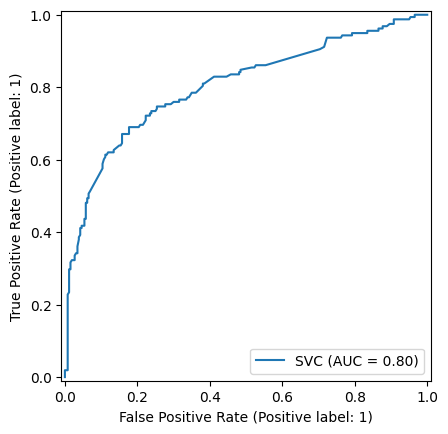

In [90]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(sfm.best_estimator_, X_te, y_te)

# Rete neurale densa

In [91]:
# Importiamo tutte le librerire necessarie
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from tqdm import trange
from inspect import signature

In [92]:
X_tr = X_tr.reset_index(drop=True)
X_te = X_te.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)

y_tr = y_tr.reset_index(drop=True)
y_te = y_te.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

- dropout 0.2 nei layer;
- learning rate decrescente esponenzialmente partendo da 0.01;
- pazienza sulla validation loss di 5 epoche;
- mindelta: 0.01;
- modelcheckpoint sul miglior modello rispetto alla minima val loss.

In [93]:
config = {
    "learning_rate": 0.01,
    "batch_size": 64,
    "epochs": 20,
    "patience": 5,
    "min_delta": 0.01,
    "momentum": 0.9,
    "nesterov": True,
    "train_loss": nn.NLLLoss(),
    "test_loss": nn.NLLLoss(),
    "metrics": [precision_score, recall_score, f1_score],
    "metric_average": 'macro'
}

In [94]:
class TensDataset(torch.utils.data.Dataset):
    def __init__(self, x_data, y_data):
        self.X = torch.tensor(x_data.values, dtype = torch.float32)
        self.y = torch.tensor(y_data.values, dtype = torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [95]:
train_data = TensDataset(X_tr, y_tr)
val_data = TensDataset(X_val, y_val)
test_data = TensDataset(X_te, y_te)

In [96]:
input_dim = X_tr.shape[1]
input_dim

4

In [97]:
device = "cpu"

In [98]:
class ReteDensa(nn.Module):
    def __init__(self, input_dim):
        super(ReteDensa, self).__init__()
        self.network= nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 2),
            nn.LogSoftmax(dim=1)        
        )
    def forward(self, x):
        return self.network(x).squeeze(1)


In [99]:
model = ReteDensa(input_dim = input_dim).to(device)
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
ReteDensa                                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       640
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─ReLU: 2-4                         --
│    └─Dropout: 2-5                      --
│    └─Linear: 2-6                       2,080
│    └─ReLU: 2-7                         --
│    └─Dropout: 2-8                      --
│    └─Linear: 2-9                       528
│    └─ReLU: 2-10                        --
│    └─Dropout: 2-11                     --
│    └─Linear: 2-12                      34
│    └─LogSoftmax: 2-13                  --
Total params: 11,538
Trainable params: 11,538
Non-trainable params: 0

In [100]:
from torch.optim import Adam

In [101]:
opt = Adam(params=model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)

In [102]:
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma = 0.99)

In [103]:
def make_dataloaders(train_data, val_data, test_data, 
                     batch=config["batch_size"], prefetch=None, no_pagemem=False):

    """costruisce i dataloaders di train, validazione e test a partire dai rispettivi dataset.

    Args:
        train_data (torch.utils.data.Dataset): data set di training
        val_data (torch.utils.data.Dataset): data set di validazione
        test_data (torch.utils.data.Dataset): data set di test
        batch (int, optional): dimenssione del batch. Defaults to config["batch_size"].
        prefetch (int, optional): n. di batch precaricati in ogni sottoprocesso. Defaults to 12.
        pagemem (bool, optional): uso della memoria non paginata per i tensori. Defaults to True.
    
    Returns:
        dataloaders (tuple[torch.utils.data.Dataloader, torch.utils.data.Dataloader, torch.utils.data.Dataloader]): una tupla contenente i tre dataloader
    """
    # Creiamo i data loaders che saranno gli iteraboili che generano i batch di
    # addestramento e/o test
    train_dataloader = DataLoader(train_data,
                                batch_size=batch,           # Imposta la dimensione del batch
                                shuffle=True,               # Shuffling dei batch tra un'epoca e l'altra
                                num_workers=0,              # Numero dei sottoprocessi di caricamento dei dati
                                prefetch_factor=prefetch,   # Batch precaricati da ogni sottoprocesso
                                pin_memory=no_pagemem)      # Usa la memoria non paginata per muovere i tensori
                                                            # da CPU a GPU
    val_dataloader = DataLoader(val_data,
                                batch_size=batch,
                                shuffle=True,
                                num_workers=0,
                                prefetch_factor=prefetch,
                                pin_memory=no_pagemem)

    test_dataloader = DataLoader(test_data,
                                batch_size=batch,
                                shuffle=True,
                                num_workers=0,
                                prefetch_factor=prefetch,
                                pin_memory=no_pagemem)

    # semplice investigazione della shape dei tensori: usiamo il primo
    # batch del test dataloader come esempio
    for X, y in test_dataloader:
        print(f"Shape e tipo dei campioni: {X.shape}, {X.dtype}")
        print(f"Shape e tipo delle etichette: {y.shape} {y.dtype}")
        break
    
    dataloaders = (train_dataloader, val_dataloader, test_dataloader)
    return dataloaders


In [104]:
class EarlyStopping:
    """Implementazione del Early Stopping
    
        Args:
            patience (int): numero epoche di pazienza
            min_delta (float): incremento minimo della loss di validazione 
    """
    def __init__(self, 
                 patience=config["patience"], 
                 min_delta=config["min_delta"]):

        self.patience = patience
        self.min_delta = min_delta              # valore minimo di decrescita della loss di validazione all'epoca corrente
                                                # per asserire che c'è un miglioramenti della loss
        self.counter = 0                        # contatore delle epoche di pazienza
        self.early_stop = False                 # flag di early stop
        self.min_validation_loss = torch.inf    # valore corrente ottimo della loss di validazione

    def __call__(self, validation_loss):
        """chiamata in forma funzionale dell'oggetto di classe EarlySopping

        Args:
            validation_loss (float): valore della loss di validazione
        """

        # chiamata in forma funzionale dell'oggetto di classe EarlySopping

        if (validation_loss + self.min_delta) >= self.min_validation_loss:  # la loss di validazione non decresce
            self.counter += 1                                               # incrementiamo il contatore delle epoche di pazienza
            if self.counter >= self.patience:
                self.early_stop = True
        else:                                                   # c'è un miglioramento della loss:
            self.min_validation_loss = validation_loss          # consideriamo la loss corrente
                                                                # come nuova loss ottimale
            self.counter = 0

In [105]:
train_loader, val_loader, test_loader = make_dataloaders(train_data=train_data, 
                                                         test_data= test_data,
                                                         val_data= val_data,
                                                         batch = config["batch_size"])

Shape e tipo dei campioni: torch.Size([64, 4]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


## Da modificare: 

In [106]:
def save_model(net, optimizer, current_epoch, train_loss, val_loss, test_loss, accuracy, metrics, path):
    """Salvataggio del modello con tutte le informazioni di stato e le metriche in un file pickle

    Args:
        net (torch.nn.Module): classe del modello neurale
        optimizer (torch.optim.Optimizer): ottimizzatore
        current_epoch (int): numero di epoche di addestramento
        train_loss (list[float]): lista dei valori della loss di addestramento
        val_loss (list[float]): lista dei valori della loss di validazione
        test_loss (list[float]): lista dei valori della loss di test
        accuracy (list[float]): lista dei valori dell'accuracy
        metrics (dict[list[float]]): liste dei valori delle metriche definite dall'utente
        path (os.path): percorso completo del file di salvataggio
    """

    # Abbiamo deciso per queste informazioni, ma possiamo caricare qualunque cosa
    to_save = {
            'epoch': current_epoch,
            'model_state_dict': net.state_dict(),               # configurazione di tutti i layer *addestrabili* del modello
            'optimizer_state_dict': optimizer.state_dict(),     # configurazione e operparametri dell'ottimizzatore
            'training_loss': train_loss,
            'validation_loss': val_loss,
            'test_loss': test_loss,
            'accuracy': accuracy
    }
    
    to_save.update(metrics)
    
    torch.save(to_save, path)


def load_model(path, model, optimizer, device = None):
    """  Ricarichiamo il dizionario e restituiamo la tupla delle informazioni. La rete e l'ottimizzatore devono essere inizializzati prima chiamare la funzione

    Args:
        path (os.path): percorso completo del file del modello
        model (torch.nn.Module): modello inizializzato
        optimizer (torch.optim.Optimizer): ottimizzatore inizializzato
        device (torch.device or int or str): device di caricamento del modello. Defaults to None.

    Returns:
        tuple[torch.nn.Module, torch.optim.Optimizer, Any]: tupla contenente il modello, l'ottimizzatore e tutto lo stato conservato da ``save_model()``
    """


    # Se il device è specificato e non è la CPU, allora muoviamo il modello sul device
    if device != None and device != 'cpu':
        model.to(device)

    # carichiamo il model checkpoint
    checkpoint = torch.load(path)

    # inizializziamo lo stato del modello e dell'ottimizzatore
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # restituiamo tutte le informazioni in una tupla
    return (model,
            optimizer,
            checkpoint
            )

In [107]:
def train_loop(model, 
               dataloader, 
               optimizer, 
               device, 
               pbar, 
               loss_fn=config["train_loss"]):
    """Ciclo di addestramento sui batch di un'epoca

    Args:
        model (torch.nn.Module): classe del modello neurale
        dataloader (torch.utils.data.Dataloader): dataloader di addestramento
        optimizer (torch.optim.Optimizer): ottimizzatore
        device (torch.device or int or str): device di esecuzione dell'addestramento
        pbar (tqdm): progress bar
        loss_fn (optional): loss di addestramento definita in ``torch.nn``. Defaults to config["train_loss"]

    Returns:
        float: loss media sui batch
    """

    num_batches = len(dataloader)
    epoch_loss = 0.0

    # Impostiamo la modalità di training del modello: è una best practice che serve per il
    # dropout e/o batch normalization
    model.train()
    for _, (X, y) in zip(pbar,dataloader):      # questa iterazione fatta così garantisce l'avanzamento della progress
                                                # bar mentre i batch vengono prelevati dal dataloader

        # Spostiamo esplicitamente i tensori sul device di computazione
        X, y = X.to(device), y.to(device)

        # Passo esplicito di addestramento
        optimizer.zero_grad()                   # azzeriamo i gradienti dell'iterata precedente

        # Calcoliamo la loss ed effettuiamo la predizione del minibatch
        logits = model(X)
        batch_loss = loss_fn(logits, y)

        epoch_loss += batch_loss.item()

        batch_loss.backward()             # step di backpropagation

        optimizer.step()                  # passo di ottimizzazione e aggiornamento dei parametri


    # Ritorniamo la loss media dell'epoca
    return epoch_loss/num_batches

def eval_loop(model, 
              dataloader, 
              device, 
              loss_fn=config["test_loss"], 
              metrics=config["metrics"],
              average=config["metric_average"]):
    """ciclo di test/validazione su un'epoca

    Args:
        model (torch.nn.Module): classe del modello neurale
        dataloader (torch.utils.data.Dataloader): dataloader di test/validazione
        device (torch.device or int or str): device di esecuzione dell'addestramento
        loss_fn (optional): loss di test/validazione definita in ``torch.nn``. Defaults to config["test_loss"]
        metrics (list[callable(y_true, y_pred, **kwargs)], optional): lista delle metriche definite dall'utente che possono o meno avere un parametro average per la gestione delle metriche multiclasse. Defaults to config["metrics"]
        average (string|None, optional): parametro di calcolo delle metriche medie multiclasse. Segue la convenzione di sklearn: {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’} or None. Defaluts to config["metric_average"]

    Returns:
        tuple[float, float, dict[]]: loss di test/validazione, accuracy, dizionario dei valori delle metriche definite nella configurazione e calcolate sull'epoca
    """

    # Impostiamo la modalità di valutazione del modello: è una best practice che serve per il
    # dropout e/o batch normalization
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    y_score = []

    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            # Spostiamo esplicitamente i tensori sul device di computazione
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # L'accuracy sul batch si calcola creando il tensore di dimensione pari al batch
            # per cui i massimi argomenti di ogni predizione sono uguali alla classe predetta
            # per il singolo campione, poi convertendo questo tensore di booleani in un vettore
            # binario di tipo float, sommando i valori 1 ed estraendo lo scalare contenuto nel tensore risultato
            accuracy += (pred.argmax(1) == y.long()).type(torch.float).sum().item()

            y_true.extend(y.cpu().detach().tolist())
            y_pred.extend(pred.argmax(1).cpu().detach().tolist())
            y_score.extend(torch.exp(pred)[:,1].cpu().detach().tolist())

    test_loss /= num_batches
    accuracy /= size            # Per quanto detto prima, l'accuracy media va calcolata sulla dimensione del data set

    # Calcoliamo il dizionario delle metriche per epoca
    epoch_metrics = {}
    for metric in metrics:
        epoch_metrics[metric.__name__] = metric(y_true, y_pred, average=average) \
                if 'average' in signature(metric).parameters.keys() \
                else metric(y_true, y_pred)

    return test_loss, accuracy, epoch_metrics, y_true, y_pred, y_score

 
def train_test(model,
               optimizer,
               device,
               train_dataloader,
               test_dataloader,
               epochs=config["epochs"],
               train_loss_fn=config["train_loss"],
               test_loss_fn=config["test_loss"],
               early_stopping=None,     # posso addestrare senza early stopping
               val_dataloader=None,     # e in questo caso non c'è validation set
               scheduler=None,          # possibile scheduler per monitorare l'andamento di un iperparametro, tipicamente il learning rate
               metrics=config["metrics"],
               average=config["metric_average"]):
    """Ciclo di addestramento completo con test, early stopping e scheduler del learning rate

    Args:
        model (torch.nn.Module): classe del modello neurale
        optimizer (torch.optim.Optimizer): ottimizzatore
        device (torch.device or int or str): device di esecuzione dell'addestramento/test
        train_dataloader (torch.utils.data.Dataloader): dataloader di addestramento
        test_dataloader (torch.utils.data.Dataloader): dataloader di test
        epochs (int): numero di epoche. Defaults to config["epochs"]
        train_loss_fn (optional): loss di addestramento definita in ``torch.nn``. Defaults to config["train_loss"]
        test_loss_fn (optional): loss di test/validazione definita in ``torch.nn``. Defaults to config["test_loss"]
        early_stopping (EarlyStopping, optional): classe di early stopping se presente. Defaults to None.
        metrics (list[callable(y_true, y_pred, **kwargs)], optional): lista delle metriche definite dall'utente che possono o meno avere un parametro average per la gestione delle metriche multiclasse. Defaults to config["metrics"]
        average (string|None, optional): parametro di calcolo delle metriche medie multiclasse. Segue la convenzione di sklearn: {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’} or None. Defaluts to config["metric_average"]

    Returns:
        tuple[float, float, float, list[float], dict[list[float]]]: valori delle loss di train, test e validazione, lista dei valori di accuracy per epoca, dizionario con le liste dei valori delle metriche per epoca
    """
                                    

    # liste dei valori di loss e accuracy epoca per epoca per il plot
    train_loss, validation_loss, test_loss = [], [], []
    accuracy = []
    # 1. AGGIUNGI QUESTA RIGA ALL'INIZIO DELLA FUNZIONE
    best_val_loss = float('inf')
    
    # dizionario delle liste dei valori delle metriche di test epoca per epoca
    test_metrics = {}   
    for metric in metrics:
        test_metrics[metric.__name__] = []

    num_batches = len(train_dataloader.batch_sampler) # il campionatore dei batch del dataloader ha il protocollo 
                                                      # __len__ e può fornirci il numero dei batch campionabili

    # Ciclo di addestramento con early stopping
    for epoch in range(1,epochs+1):

        # Progress bar
        pbar = trange(num_batches)
        pbar.set_description(desc='Epoch {:4d}'.format(epoch))

        epoch_train_loss = train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=train_loss_fn)
        train_loss.append(epoch_train_loss)

        # validation se è presente val_dataloader
        if val_dataloader != None:
                epoch_validate_loss, *_ = eval_loop(model, val_dataloader, device, loss_fn=test_loss_fn, metrics=metrics, average=average)
                validation_loss.append(epoch_validate_loss)

        # test 
        epoch_test_loss, epoch_accuracy, epoch_metrics, *_ = eval_loop(model, test_dataloader, device, loss_fn=test_loss_fn, metrics=metrics, average=average)

        test_loss.append(epoch_test_loss)
        accuracy.append(epoch_accuracy)
        for metric in metrics:
            test_metrics[metric.__name__].append(epoch_metrics[metric.__name__])


        val_str = f'Validation loss: {epoch_validate_loss:6.4f}\n' if val_dataloader != None else ' '

        print(f"Train loss: {epoch_train_loss:6.4f}\n{val_str}Test loss: {epoch_test_loss:6.4f} Accuracy: {epoch_accuracy:6.2f}\nMetrics:")
        
        for label, metric in epoch_metrics.items():     
              print(f'{label}: {metric:6.2f} ', end=' ')
        
        print()

        # --- SOSTITUISCI IL BLOCCO EARLY STOPPING CON QUESTO ---
        if early_stopping != None:
            # Se la loss di questa epoca batte il record precedente, salvi il Checkpoint
            if epoch_validate_loss < best_val_loss:
                best_val_loss = epoch_validate_loss
                save_model(model, optimizer, epoch, train_loss, validation_loss, test_loss, accuracy, test_metrics, "best_model.pth")

            early_stopping(epoch_validate_loss)    
            if early_stopping.early_stop:
                break
        # scheduler dell'iperparametro
        if scheduler != None:
            scheduler.step()

    return train_loss, validation_loss, test_loss, accuracy, test_metrics

In [108]:
es = EarlyStopping()

t_loss, v_loss, te_loss, n_accuracy, n_metrics = train_test(
    model = model, 
    optimizer=opt,
    scheduler=scheduler,
    early_stopping=es,
    device=device,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    val_dataloader=val_loader,
)

Epoch    1:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch    1: 100%|██████████| 13/13 [00:00<00:00, 19.87it/s]


Train loss: 0.5391
Validation loss: 0.5237
Test loss: 0.5552 Accuracy:   0.71
Metrics:
precision_score:   0.70  recall_score:   0.71  f1_score:   0.70  


Epoch    2: 100%|██████████| 13/13 [00:00<00:00, 53.77it/s]


Train loss: 0.4636
Validation loss: 0.5914
Test loss: 0.5184 Accuracy:   0.78
Metrics:
precision_score:   0.77  recall_score:   0.76  f1_score:   0.76  


...

Train loss: 0.4117
Validation loss: 0.4649
Test loss: 0.4937 Accuracy:   0.78
Metrics:
precision_score:   0.77  recall_score:   0.76  f1_score:   0.76  


Epoch    8: 100%|██████████| 13/13 [00:00<00:00, 14.23it/s]


Train loss: 0.4221
Validation loss: 0.5225
Test loss: 0.4793 Accuracy:   0.78
Metrics:
precision_score:   0.81  recall_score:   0.73  f1_score:   0.74  


Epoch    9: 100%|██████████| 13/13 [00:00<00:00, 68.50it/s]


Train loss: 0.4169
Validation loss: 0.5118
Test loss: 0.5480 Accuracy:   0.77
Metrics:
precision_score:   0.75  recall_score:   0.75  f1_score:   0.75  


In [109]:
def displayLosses(train_loss, test_loss, validation_loss):
    """plot dell'andamento delle loss di addestramento/validazione/test lungo le epoche di addestramento

    Args:
        train_loss (list[float]): loss di addestramento
        test_loss (list[float]): loss di test
        validation_loss (list[float]): loss di validazione
    """
        
    epochs = range(1, len(train_loss)+1) # calcolo del range delle epoche
    
    plt.plot(epochs, train_loss, label='training loss')
    plt.plot(epochs,validation_loss, label='validation loss')
    plt.plot(epochs, test_loss, label='test loss')
    plt.legend(loc='lower right')
    plt.title("Loss di addestramento")
    plt.ylim(0,1)
    plt.show()
    

def displayMetrics(accuracy, metrics):
    """plot dell'andamento dell'accuracy di addestramento e delle metriche di test lungo le epoche di addestramento

    Args:
        accuracy (list[float]): accuracy di addestramento
        metrics (tuple[list[float]]): dizionario delle metriche di test
    """
    epochs = range(1, len(accuracy)+1) # calcolo del range delle epoche
    
    plt.plot(epochs, accuracy, label="train acc.")
    
    for label, metric in metrics.items():
        plt.plot(epochs, metric, label=label)
    
    plt.legend(loc='lower right')
    plt.title("Metriche")
    plt.ylim(0,1)
    plt.show()

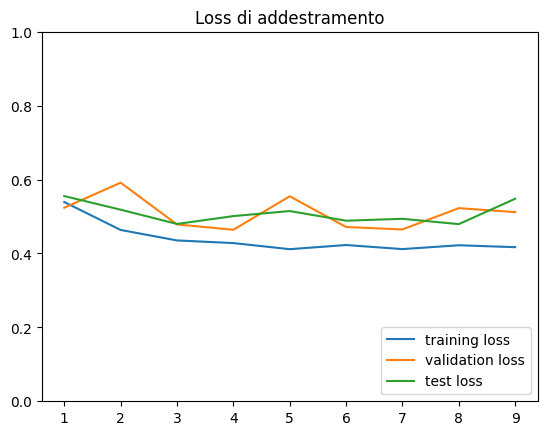

In [110]:
displayLosses(t_loss, te_loss, v_loss)

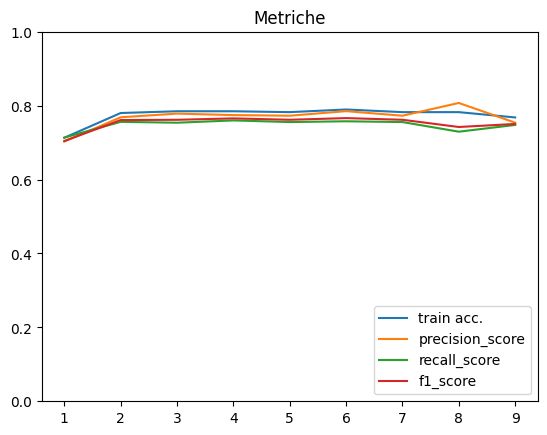

In [111]:
displayMetrics(n_accuracy, n_metrics)

Implementare anche una callback di model checkpoint per il salvataggio del solo miglior modello rispetto alla minima validation loss.

In [112]:
from sklearn.metrics import confusion_matrix, accuracy_score, RocCurveDisplay

(mod, opt, model_checkpoint) =load_model("best_model.pth", 
                                         model,
                                         opt,
                                         device)

In [113]:
test_loss, accuracy, epoch_metrics, y_true, y_pred, y_score = eval_loop(mod, 
                                                              test_loader, 
                                                              device = device)

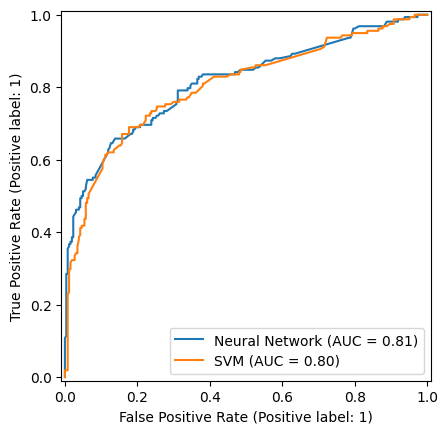

In [114]:
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_true, y_score, name="Neural Network", ax = ax)
RocCurveDisplay.from_estimator(sfm.best_estimator_, X_te, y_te, name="SVM", ax = ax)

In [115]:
print(classification_report(y_te, y_pred_svc))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       260
           1       0.75      0.62      0.68       158

    accuracy                           0.78       418
   macro avg       0.77      0.75      0.76       418
weighted avg       0.78      0.78      0.77       418



In [116]:
print(accuracy)

0.784688995215311


In [117]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_te, y_pred_svc)
cm

array([[228,  32],
       [ 60,  98]])

In [118]:
cm1 = confusion_matrix(y_true, y_pred)
cm1

array([[224,  36],
       [ 54, 104]])